# Machine Learning Algorithms
### Online Shoppers Intention Dataset
Algorithms covered: **Logistic Regression** (No Reg / L1 / L2) · **SVM** (Linear / RBF) · **K-Means**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
df = df.drop_duplicates()
print('Shape after deduplication:', df.shape)
df.head()

Shape after deduplication: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Separate features and target
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)

# One-hot encode categorical + boolean columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print('Features shape:', X.shape)
print('Class distribution (0=No Purchase, 1=Purchase):')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Features shape: (12205, 26)
Class distribution (0=No Purchase, 1=Purchase):
Revenue
0    10297
1     1908
Name: count, dtype: int64
Revenue
0    0.844
1    0.156
Name: proportion, dtype: float64


In [4]:
# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (critical for LR and SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print('X_train:', X_train_sc.shape, '| X_test:', X_test_sc.shape)

X_train: (9764, 26) | X_test: (2441, 26)


In [5]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, compute predictions and print a structured report."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    cv  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Test Accuracy  : {acc:.4f}")
    print(f"  CV Accuracy    : {cv:.4f}  (5-fold on train set)")
    print()
    print(classification_report(y_te, y_pred, target_names=['No Purchase', 'Purchase']))
    return model, y_pred, acc

---
## 2. Logistic Regression
Logistic Regression models the probability of a binary outcome using the sigmoid function. Regularization controls how large coefficients are allowed to grow.

### 2.1 No Regularization
`penalty=None` removes the regularization term entirely. The optimizer minimizes pure log-loss. This gives the largest (unpenalized) coefficients and can overfit on noisy or high-dimensional data, but serves as a useful baseline.

In [6]:
lr_noreg, pred_noreg, acc_noreg = evaluate(
    'Logistic Regression — No Regularization',
    LogisticRegression(
        penalty=None,
        max_iter=2000,
        random_state=42,
        class_weight='balanced',   # compensates for class imbalance (~85/15)
        solver='lbfgs'
    ),
    X_train_sc, y_train, X_test_sc, y_test
)


  Logistic Regression — No Regularization
  Test Accuracy  : 0.8513
  CV Accuracy    : 0.8521  (5-fold on train set)

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.91      2059
    Purchase       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.82      0.77      2441
weighted avg       0.89      0.85      0.86      2441



### 2.2 L1 Regularization (Lasso)
Adds the **sum of absolute coefficient values** to the loss: `loss + (1/C) * Σ|wᵢ|`. This drives many coefficients to **exactly zero**, effectively performing feature selection. Very useful when many features are irrelevant. Higher `C` = weaker regularization.

In [7]:
lr_l1, pred_l1, acc_l1 = evaluate(
    'Logistic Regression — L1 Regularization',
    LogisticRegression(
        penalty='l1',
        C=1.0,
        max_iter=2000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'   # required for L1 in sklearn
    ),
    X_train_sc, y_train, X_test_sc, y_test
)

n_zero = np.sum(lr_l1.coef_[0] == 0)
print(f'Coefficients zeroed out by L1: {n_zero} / {len(lr_l1.coef_[0])}')


  Logistic Regression — L1 Regularization
  Test Accuracy  : 0.8513
  CV Accuracy    : 0.8520  (5-fold on train set)

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.91      2059
    Purchase       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.82      0.77      2441
weighted avg       0.89      0.85      0.86      2441

Coefficients zeroed out by L1: 0 / 26


### 2.3 L2 Regularization (Ridge)
Adds the **sum of squared coefficient values** to the loss: `loss + (1/C) * Σwᵢ²`. Shrinks all coefficients toward zero but **never exactly zero** — all features remain in the model. This is sklearn's default and generally the most robust choice when most features carry some signal.

In [8]:
lr_l2, pred_l2, acc_l2 = evaluate(
    'Logistic Regression — L2 Regularization',
    LogisticRegression(
        penalty='l2',
        C=1.0,
        max_iter=2000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs'
    ),
    X_train_sc, y_train, X_test_sc, y_test
)


  Logistic Regression — L2 Regularization
  Test Accuracy  : 0.8513
  CV Accuracy    : 0.8522  (5-fold on train set)

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.91      2059
    Purchase       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.82      0.77      2441
weighted avg       0.89      0.85      0.86      2441



### Logistic Regression — Visual Comparison

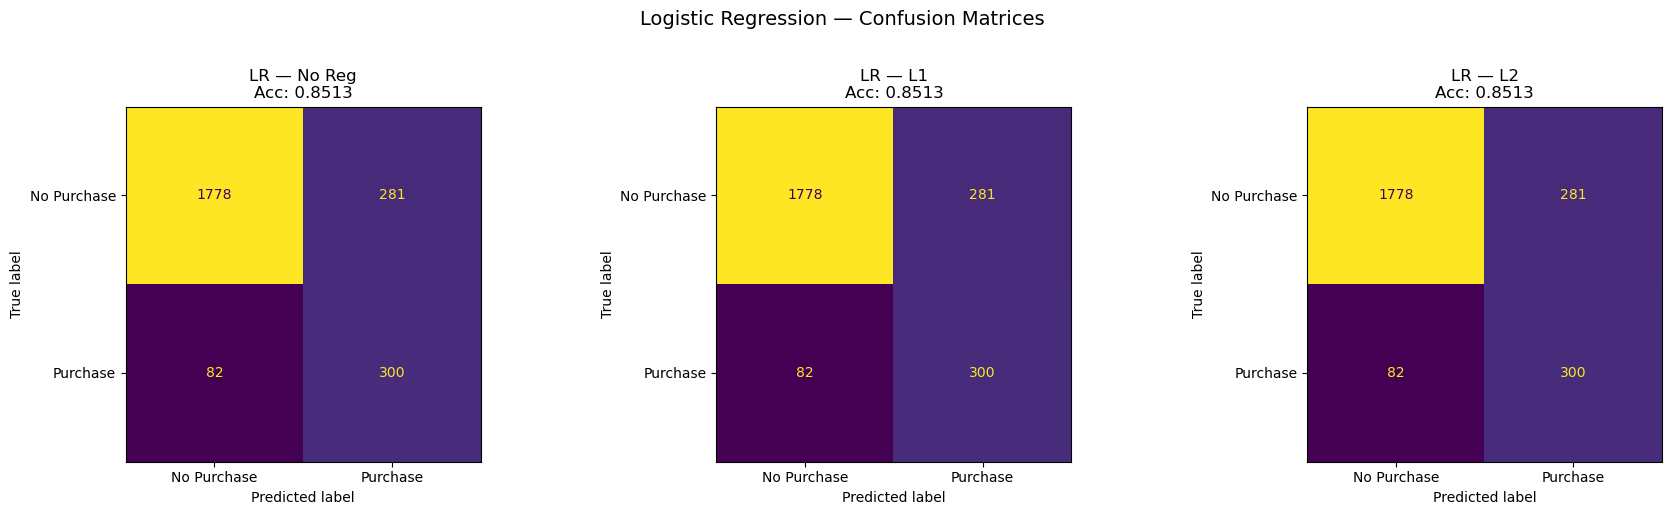

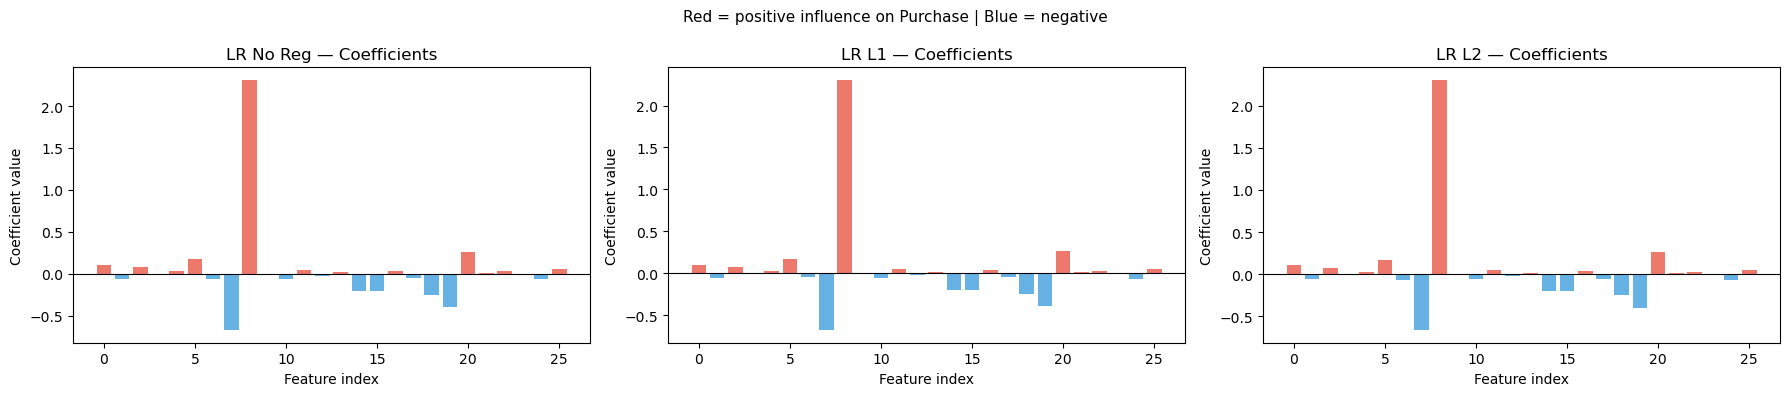

In [9]:
lr_names  = ['No Reg', 'L1', 'L2']
lr_models = [lr_noreg, lr_l1, lr_l2]
lr_preds  = [pred_noreg, pred_l1, pred_l2]
lr_accs   = [acc_noreg, acc_l1, acc_l2]

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, pred in zip(axes, lr_names, lr_preds):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase']).plot(ax=ax, colorbar=False)
    ax.set_title(f'LR — {name}\nAcc: {accuracy_score(y_test, pred):.4f}')
plt.suptitle('Logistic Regression — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Coefficient magnitude per variant
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, name, model in zip(axes, lr_names, lr_models):
    coef = model.coef_[0]
    colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef]
    ax.bar(range(len(coef)), coef, color=colors, alpha=0.75)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'LR {name} — Coefficients')
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Coefficient value')
plt.suptitle('Red = positive influence on Purchase | Blue = negative', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Support Vector Machine (SVM)
SVMs find the hyperplane that **maximises the margin** between classes. The `C` parameter trades off margin width vs. misclassification penalty. The **kernel** controls the geometry of the decision boundary.

### 3.1 Linear Kernel
Finds a flat hyperplane in the original feature space. Equivalent to a linear boundary. Fast and interpretable — works well when classes are (approximately) linearly separable.

In [10]:
svm_linear, pred_svm_linear, acc_svm_linear = evaluate(
    'SVM — Linear Kernel',
    SVC(
        kernel='linear',
        C=1.0,
        random_state=42,
        class_weight='balanced'
    ),
    X_train_sc, y_train, X_test_sc, y_test
)


  SVM — Linear Kernel
  Test Accuracy  : 0.8759
  CV Accuracy    : 0.8767  (5-fold on train set)

              precision    recall  f1-score   support

 No Purchase       0.95      0.90      0.92      2059
    Purchase       0.58      0.76      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.79      2441
weighted avg       0.89      0.88      0.88      2441



### 3.2 RBF Kernel (Radial Basis Function)
Implicitly maps data into a high-dimensional space where non-linear boundaries become linear. Controlled by:
- **`C`** — how much to penalize misclassification (higher = tighter fit)
- **`gamma='scale'`** — influence radius of a single sample (auto-scaled by sklearn as `1 / (n_features * X.var())`)

In [11]:
svm_rbf, pred_svm_rbf, acc_svm_rbf = evaluate(
    'SVM — RBF Kernel',
    SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42,
        class_weight='balanced'
    ),
    X_train_sc, y_train, X_test_sc, y_test
)


  SVM — RBF Kernel
  Test Accuracy  : 0.8628
  CV Accuracy    : 0.8593  (5-fold on train set)

              precision    recall  f1-score   support

 No Purchase       0.95      0.88      0.92      2059
    Purchase       0.54      0.76      0.63       382

    accuracy                           0.86      2441
   macro avg       0.75      0.82      0.77      2441
weighted avg       0.89      0.86      0.87      2441



### SVM — Visual Comparison

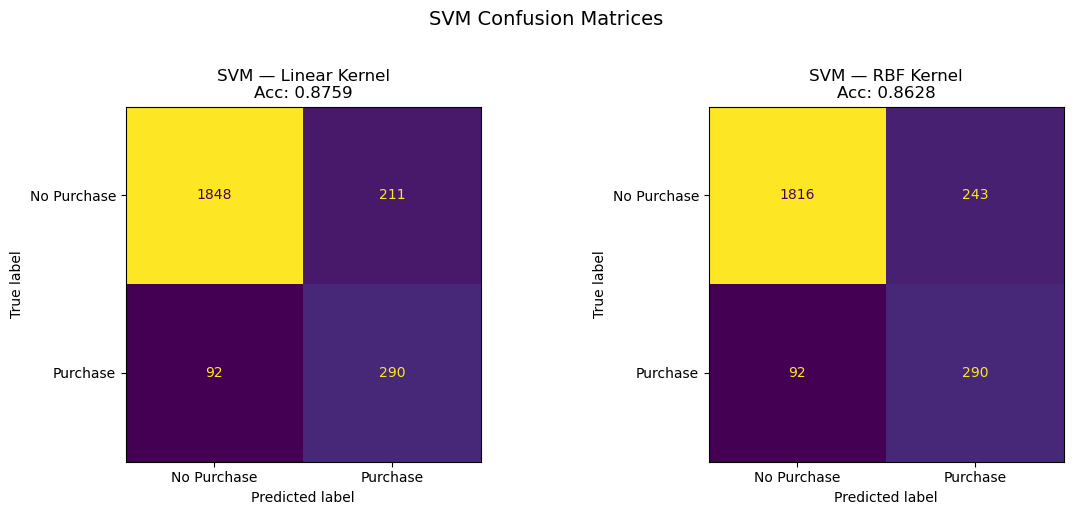

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, pred in zip(axes, ['Linear', 'RBF'], [pred_svm_linear, pred_svm_rbf]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase']).plot(ax=ax, colorbar=False)
    ax.set_title(f'SVM — {name} Kernel\nAcc: {accuracy_score(y_test, pred):.4f}')
plt.suptitle('SVM Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. K-Means Clustering

> **Can K-Means work for this problem?**
>
> K-Means is **unsupervised** — it never sees the `Revenue` labels during training. Instead of predicting a class, it partitions samples into `k` groups based on feature similarity.
> We can still use it here in two ways:
> 1. **External validation** — check how well the discovered clusters align with the true labels (using ARI / NMI).
> 2. **Shopper segmentation** — find natural behavioural segments regardless of purchase outcome.
>
> **Limitation:** if the class boundary is not well-captured by Euclidean distance in feature space, cluster labels will not align with Revenue. This is common in real-world datasets.

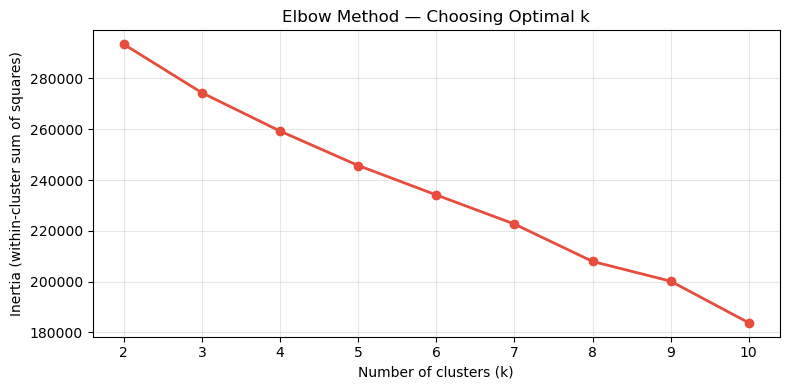

In [13]:
# Scale the full dataset for clustering (no labels used)
scaler_km = StandardScaler()
X_all_sc = scaler_km.fit_transform(X)

# Elbow method — inertia vs k
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_all_sc)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='#e74c3c', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method — Choosing Optimal k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Fit K-Means with k=2 (natural match to binary Revenue)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_sc)

# Internal validation
sil = silhouette_score(X_all_sc, cluster_labels)
print(f'Silhouette Score (k=2)       : {sil:.4f}')
print('  Ranges from -1 to 1; closer to 1 = well-separated clusters\n')

# External validation — alignment with true Revenue labels
ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)
print(f'Adjusted Rand Index (ARI)    : {ari:.4f}  (1 = perfect match with Revenue)')
print(f'Normalized Mutual Info (NMI) : {nmi:.4f}  (1 = perfect match with Revenue)')

Silhouette Score (k=2)       : 0.1879
  Ranges from -1 to 1; closer to 1 = well-separated clusters

Adjusted Rand Index (ARI)    : 0.1042  (1 = perfect match with Revenue)
Normalized Mutual Info (NMI) : 0.0226  (1 = perfect match with Revenue)


Variance explained by 2 PCs: 20.83%


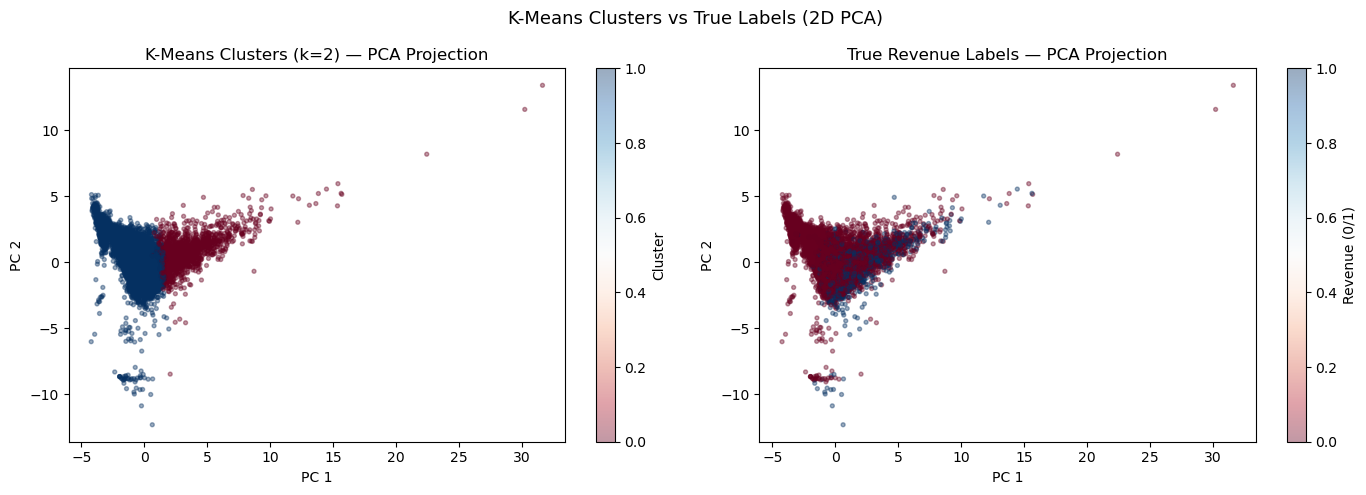

In [15]:
# Visualise with PCA (2D projection)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_sc)
print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=cluster_labels, cmap='RdBu', alpha=0.4, s=8)
axes[0].set_title('K-Means Clusters (k=2) — PCA Projection')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
plt.colorbar(scatter0, ax=axes[0], label='Cluster')

scatter1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=y.values, cmap='RdBu', alpha=0.4, s=8)
axes[1].set_title('True Revenue Labels — PCA Projection')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
plt.colorbar(scatter1, ax=axes[1], label='Revenue (0/1)')

plt.suptitle('K-Means Clusters vs True Labels (2D PCA)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Overall Summary (Supervised Models)

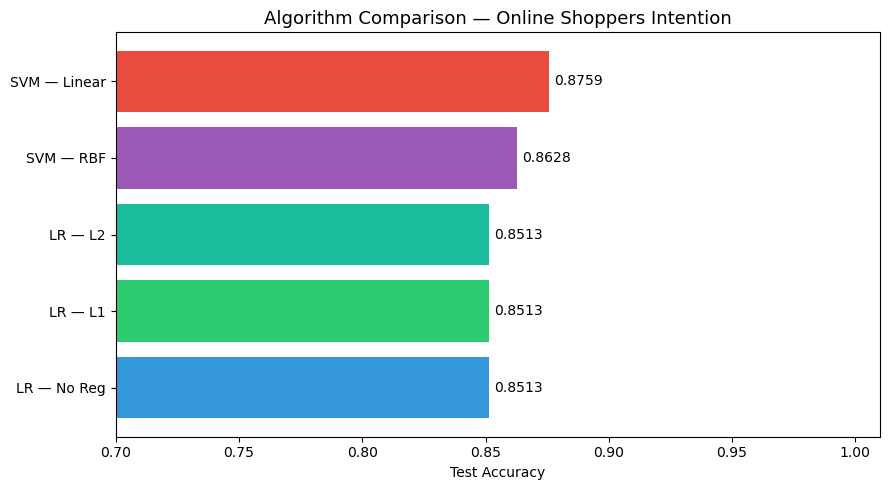


Final Leaderboard:
              Test Accuracy
SVM — Linear       0.875871
SVM — RBF          0.862761
LR — No Reg        0.851290
LR — L1            0.851290
LR — L2            0.851290


In [16]:
results = {
    'LR — No Reg'   : acc_noreg,
    'LR — L1'       : acc_l1,
    'LR — L2'       : acc_l2,
    'SVM — Linear'  : acc_svm_linear,
    'SVM — RBF'     : acc_svm_rbf,
}

df_res = pd.DataFrame.from_dict(results, orient='index', columns=['Test Accuracy'])
df_res = df_res.sort_values('Test Accuracy', ascending=True)

colors = ['#3498db', '#2ecc71', '#1abc9c', '#9b59b6', '#e74c3c']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_res.index, df_res['Test Accuracy'], color=colors)
ax.set_xlim(0.70, 1.01)
ax.set_xlabel('Test Accuracy')
ax.set_title('Algorithm Comparison — Online Shoppers Intention', fontsize=13)
for bar, val in zip(bars, df_res['Test Accuracy']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\nFinal Leaderboard:')
print(df_res.sort_values('Test Accuracy', ascending=False).to_string())

---
## Key Takeaways

| Algorithm | Key Hyperparameter | Strength | Watch out for |
|---|---|---|---|
| **LR — No Reg** | — | Clean baseline, max interpretability | Overfits on noisy data |
| **LR — L1** | `C` | Auto feature selection (zeros coefficients) | May underfit if most features matter |
| **LR — L2** | `C` | Robust shrinkage, stable | Keeps all features (no selection) |
| **SVM — Linear** | `C` | Fast, great for linear boundaries | Underfits complex patterns |
| **SVM — RBF** | `C`, `gamma` | Handles non-linear boundaries | Slow on large datasets; sensitive to params |
| **K-Means** | `k` | Discovers natural groupings, no labels needed | Not a classifier; cluster ≠ Revenue label |

### K-Means Verdict
K-Means **works** but serves a different purpose. A low ARI/NMI score means the natural geometric clusters in this dataset do not strongly correspond to the purchase/no-purchase boundary — which is expected, since Revenue is influenced by complex interactions not fully captured by Euclidean distance. K-Means is still valuable for **customer segmentation** (e.g. identifying "high-engagement non-buyers" vs "quick converters"), just not as a Revenue predictor.